# Integrals 2 notebook

Consider using the trapezoid method to integrate:

$$
f(x) = -0.19x^5 + x^4 - 2x + 3
$$

This is a simple equation that we can use to test various ideas. First, the integral can be done analytically and gives:

$$
I = \int_a^b f(x)dx = \left(\frac{-0.19}{6}x^6 + \frac{1}{5}x^5 - x^2 + 3x \right)\lvert_{0.0}^{5.0} = 120.2083333
$$

For the error, we use:

$$
\delta = \frac{h^2}{12}\left(f'(a) - f'(b) \right) = \frac{h^2}{12}\left(f'(0.0) - f'(5.0) \right)
$$

The derivative can be calculated analytically and evaluated at each boundary:

$$
f'(x) = -0.95x^4 + 4x^3 - 2
$$
Hence:
$$
f'(0.0) = -2
$$
and
$$
f'(5.0) = -95.75
$$

In the code below, we compare the error evaluated from the difference between the trapezoid integral and 120.2083333 ("error\_numerical") and the error $\delta$ calculated directly using the equation above ("error\_analytical").

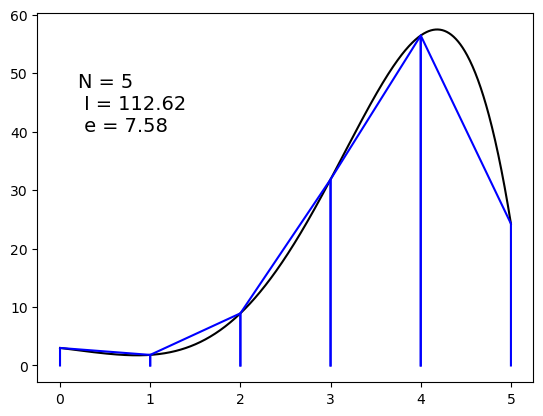

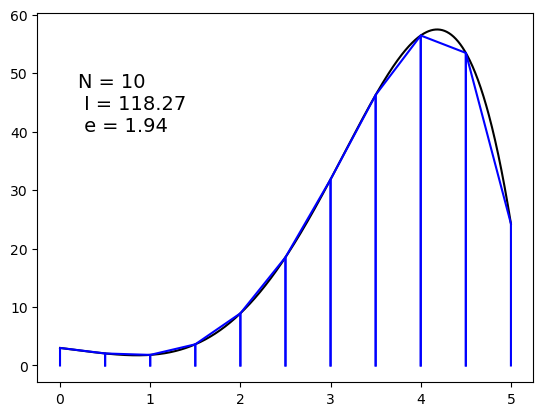

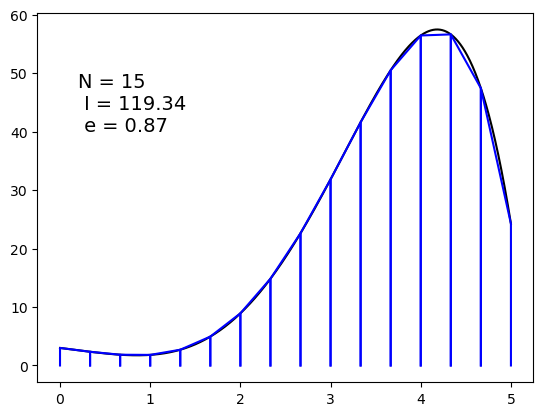

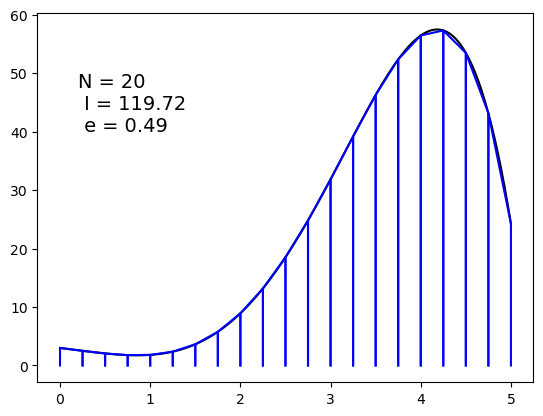

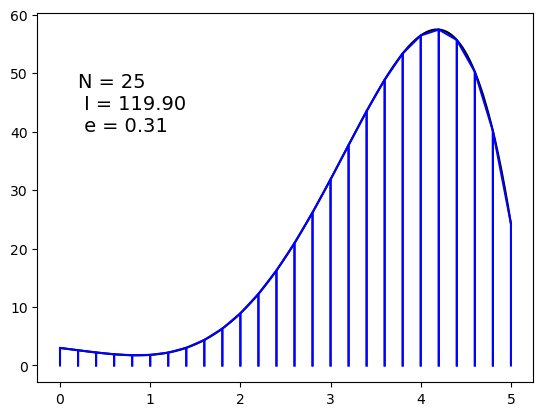

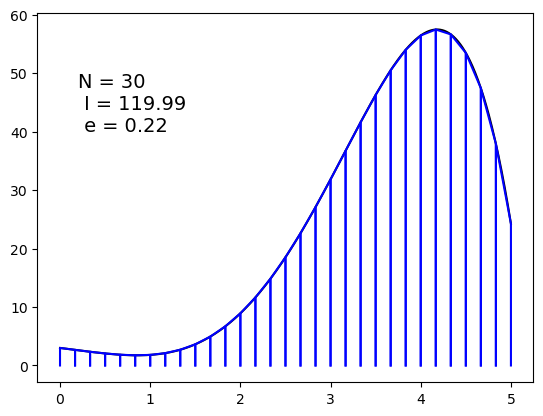

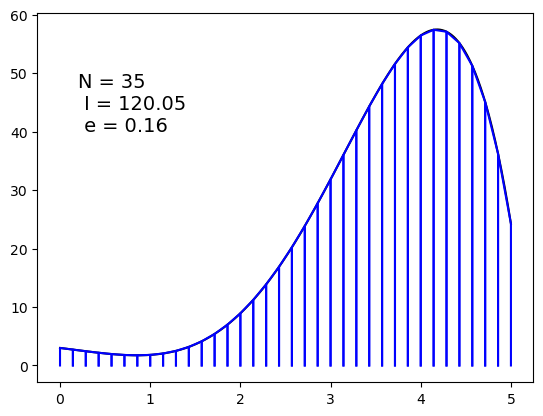

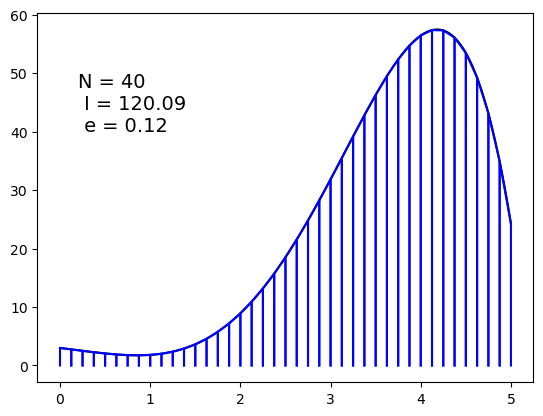

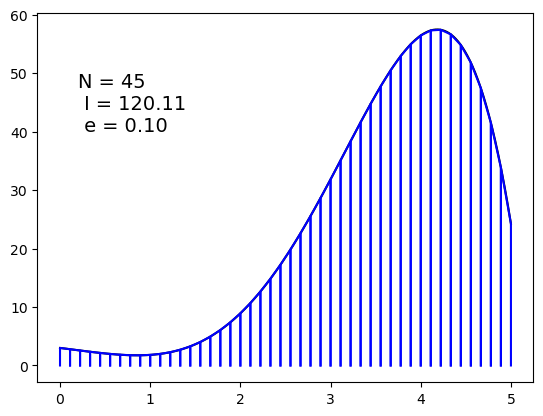

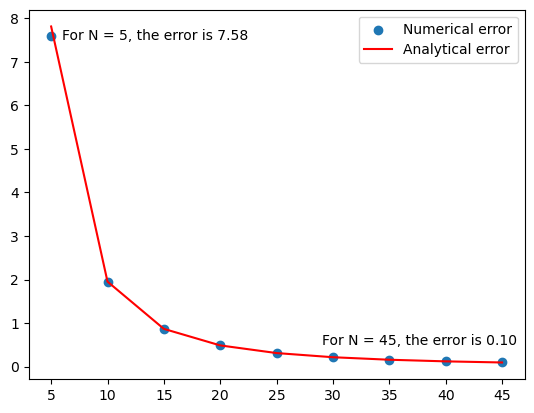

In [2]:
import numpy as np 
import matplotlib.pyplot as plt 

# Function to integrate
def fx(x):
    return -0.19*x**5 + x**4 - 2*x + 3

# Trapezoid method of integration
def integrate_trap(f, a, b, N):
    h = (b-a)/N 
    integral = 0.0
    x = np.array([], dtype='float')
    for k in range(0,N):
        xk = a + k*h 
        x = np.append(x, xk)
        integral = integral + 0.5*(f(xk) + f(xk+h))*h
    return [integral, x, h]

def error_trap(fpa, fpb, h):
    return h**2/12.0*(fpa-fpb)


# Test different values of N
N = np.array([5,10,15,20,25,30,35,40,45])
a = 0.0
b = 5.0
x = np.linspace(a, b, num=1000)

# Calculated integral from analytical equation
integral_val = 120.2083333333333

error_numerical = np.zeros(N.size)
error_analytical = np.zeros(N.size)

# The derivatives at the edges
fpa = -2
fpb = -95.75

# Test different values of N
for i, n in enumerate(N):
    integral, xk, h = integrate_trap(fx, a, b, n)
    error_numerical[i] = np.abs((integral-integral_val))
    error_analytical[i] = error_trap(fpa, fpb, 5/n)

    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.plot(x, fx(x), 'k')    

    for i in range(len(xk)):
        ax.plot([xk[i], xk[i], xk[i]+h, xk[i]+h], [0, fx(xk[i]), fx(xk[i]+h), 0], 'b')

    ax.text(0.2, 40, f"N = {n} \n I = {integral:.2f} \n e = {np.abs(integral-integral_val):.2f}", fontsize=14)

fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(N, error_numerical, label="Numerical error")
ax.plot(N, error_analytical, 'r', label = "Analytical error")
ax.text(6, 7.5, f"For N = {N[0]}, the error is {error_numerical[0]:.2f}")
ax.text(29, 0.5, f"For N = {N[-1]}, the error is {error_numerical[-1]:.2f}")
ax.legend(loc='upper right')


## Adaptive method

Now consider a function for which we do not have an easy way to calculate $f'(a)$ and $f'(b)$. This could be because we are dealing with experimental data (more in the context of data analysis) or because the function is complicated enough that taking the derivative is none trivial. 

Consider the following function:

$$
f(x) = \sqrt{\cos(x^2)}
$$

We want to evaluate it from $x=0$ to $x=\sqrt{\pi/2}$ with an error in the integral of less than $\delta = 0.001$. The steps to the test are:

- Pick a value N to evaluate the integral.
- Evaluate the integral at 2N.
- Use $\delta = \frac{1}{3}(I_{N} - I_{N/2})$ to evaluate is the desired precision has been achieved. 
- Repeat as necessary.

In [27]:
def fx(x):
    return np.sqrt(np.cos(x**2))

a = 0.0
b = np.sqrt(np.pi/2)
delta = 0.00001
n = 2
integral = 0.0
error = 1

while error > delta:
    I1, _, _ = integrate_trap(fx, a, b, n)
    I2, _, _ = integrate_trap(fx, a, b, 2*n)
    error = 1/3*(I2-I1)
    n = 2*n
    print(f"The error with {n} points is {error}.")
    if error <= delta:
        integral = I2

print(f"The final value of integral with {delta} is {integral}.")

The error with 4 points is 0.034768085178615474.
The error with 8 points is 0.012349225935832653.
The error with 16 points is 0.00437946444468514.
The error with 32 points is 0.001551356871539955.
The error with 64 points is 0.0005490823502001252.
The error with 128 points is 0.0001942415907472128.
The error with 256 points is 6.869510823899934e-05.
The error with 512 points is 2.4291035799336076e-05.
The error with 1024 points is 8.588826991913951e-06.
The final value of integral with 1e-05 is 1.077341962734626.
